## Data Validation & Inspection

In [9]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, lzma
from collections import Counter


plt.style.use("dark_background")
sns.set_theme(style="darkgrid")

### Universal snapshot loader (npz / lzma destekli)

In [10]:
def load_snapshot_file(path):
    """
    Loads either a classic .npz (numpy) or an LZMA-pickled snapshot list.
    Returns: list of snapshot objects.
    """
    try:
        # Try standard .npz (not typical for RallyRobotPilot)
        data = np.load(path, allow_pickle=True)
        return data
    except Exception:
        # Fallback: LZMA + pickle (used by RallyRobotPilot)
        with lzma.open(path, "rb") as f:
            data = pickle.load(f)
        return data

### Discover dataset files

In [12]:
# 1) Dosyaları al ve korumalı seç
DATA_DIR = "../image_records"
npz_files = sorted([os.path.join(DATA_DIR, f) for f in os.listdir(DATA_DIR) if f.endswith(".npz")])

if not npz_files:
    raise RuntimeError("Klasörde .npz dosyası yok. image_records'i kontrol et.")

In [13]:
for i, fpath in enumerate(npz_files):
    size_mb = os.path.getsize(fpath) / (1024 * 1024)
    print(f"  {i+1:02d}. {os.path.basename(fpath)}  ({size_mb:.2f} MB)")

  01. record_0.npz  (77.34 MB)
  02. record_1.npz  (131.38 MB)
  03. record_2.npz  (57.24 MB)
  04. record_3.npz  (35.30 MB)
  05. record_4.npz  (110.55 MB)


### Inspect snapshot structure

In [14]:
sample_path = npz_files[3]  # ilk dosyayı örnek al
data = load_snapshot_file(sample_path)

print(f"📦 Loaded {len(data)} snapshots from {os.path.basename(sample_path)}")
print("Example snapshot type:", type(data[0]))

snap = data[min(10, len(data)-1)]  # güvenli şekilde 10. frame'i seç

print("\n🔎 Snapshot genel yapısı:")
for attr in dir(snap):
    if not attr.startswith("_"):
        try:
            val = getattr(snap, attr)
            t = type(val).__name__
            if isinstance(val, (list, tuple, np.ndarray)):
                info = f"len={len(val)}"
            else:
                info = str(val)[:80]
            print(f"• {attr:<20} | {t:<12} | {info}")
        except Exception as e:
            print(f"• {attr:<20} | Error: {e}")

package_folder: c:\Users\Unal\Desktop\Uni-Y3\course_ML_Lab\RallyRobotPilot_2025\.venv\Lib\site-packages\ursina
asset_folder: c:\Users\Unal\Desktop\Uni-Y3\course_ML_Lab\RallyRobotPilot_2025\.venv\Lib\site-packages
📦 Loaded 628 snapshots from record_3.npz
Example snapshot type: <class 'rallyrobopilot.sensing_message.SensingSnapshot'>

🔎 Snapshot genel yapısı:
• car_angle            | float        | -90.0
• car_position         | tuple        | len=3
• car_speed            | float        | 20.710832595825195
• current_controls     | tuple        | len=4
• image                | ndarray      | len=1789
• pack                 | method       | <bound method SensingSnapshot.pack of <rallyrobopilot.sensing_message.SensingSna
• raycast_distances    | tuple        | len=15
• unpack               | method       | <bound method SensingSnapshot.unpack of <rallyrobopilot.sensing_message.SensingS


- data adında bir list var ve bu listenin her bir elemanı bir SensingSnapshot nesnesi.
- data = [snapshot_0, snapshot_1, snapshot_2, ...]

### Validate all datasets (image field integrity)

In [15]:
def check_image_integrity(dataset_paths):
    summary = []
    for fpath in dataset_paths:
        try:
            data = load_snapshot_file(fpath)
            total = len(data)
            if total == 0:
                summary.append((os.path.basename(fpath), 0, 0, "⚠️ EMPTY"))
                continue

            types = Counter(type(s.image).__name__ for s in data)
            count_image = types.get("ndarray", 0)
            ratio = (count_image / total) * 100 if total > 0 else 0

            status = "✅ OK" if ratio == 100 else ("⚠️ PARTIAL" if 0 < ratio < 100 else "❌ NO IMAGES")
            summary.append((os.path.basename(fpath), total, count_image, ratio, status))
        except Exception as e:
            summary.append((os.path.basename(fpath), 0, 0, 0, f"❌ Error: {str(e)[:40]}"))
    return summary

In [16]:
summary = check_image_integrity(npz_files)

# Tablo olarak yazdır
print(f"{'File':40s} | {'Snapshots':>10s} | {'Images':>8s} | {'Ratio %':>8s} | {'Status'}")
print("-"*85)
for fname, total, count_image, ratio, status in summary:
    print(f"{fname:40s} | {total:10d} | {count_image:8d} | {ratio:8.2f} | {status}")

File                                     |  Snapshots |   Images |  Ratio % | Status
-------------------------------------------------------------------------------------
record_0.npz                             |        828 |      828 |   100.00 | ✅ OK
record_1.npz                             |        838 |      836 |    99.76 | ⚠️ PARTIAL
record_2.npz                             |        418 |      418 |   100.00 | ✅ OK
record_3.npz                             |        628 |      627 |    99.84 | ⚠️ PARTIAL
record_4.npz                             |       1021 |     1020 |    99.90 | ⚠️ PARTIAL


### Display example image (sanity check)

Loaded 838 snapshots from record_1.npz
✅ Image captured!
Shape: (1786, 1148, 3) | dtype: uint8


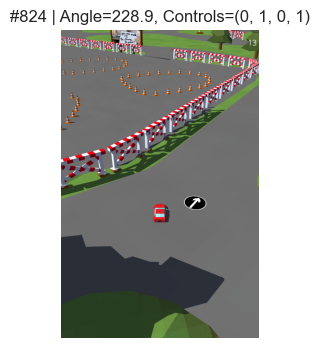

In [17]:
dataset_to_check = npz_files[1]  # istediğin dataset'i seç
data = load_snapshot_file(dataset_to_check)
print(f"Loaded {len(data)} snapshots from {os.path.basename(dataset_to_check)}")

idx = random.randint(0, len(data)-1)
snap = data[idx]

if snap.image is not None:
    print("✅ Image captured!")
    print("Shape:", snap.image.shape, "| dtype:", snap.image.dtype)

    plt.figure(figsize=(6,4))
    plt.imshow(snap.image)
    plt.title(f"#{idx} | Angle={snap.car_angle:.1f}, Controls={snap.current_controls}")
    plt.axis("off")
    plt.show()
else:
    print("❌ This frame has no image data.")

### Analyze control activity per dataset

In [18]:
def analyze_control_activity(dataset_paths):
    results = []
    for fpath in dataset_paths:
        try:
            data = load_snapshot_file(fpath)
            total = len(data)
            if total == 0:
                results.append((os.path.basename(fpath), 0, 0, 0, "⚠️ EMPTY"))
                continue

            active_count = 0
            for s in data:
                ctrl = getattr(s, "current_controls", None)
                if ctrl is not None:
                    # sayısal olarak kontrol aktif mi? (örneğin (1,0,0,0) veya (0,0,1,0))
                    if any(abs(c) > 0 for c in ctrl):
                        active_count += 1

            ratio = (active_count / total) * 100 if total > 0 else 0
            status = "✅ ACTIVE" if ratio > 50 else ("⚠️ LOW" if 0 < ratio <= 50 else "❌ NONE")
            results.append((os.path.basename(fpath), total, active_count, ratio, status))

        except Exception as e:
            results.append((os.path.basename(fpath), 0, 0, 0, f"❌ Error: {str(e)[:40]}"))
    return results


In [19]:
# Run control analysis
control_summary = analyze_control_activity(npz_files)

# Print summary table
print(f"{'File':40s} | {'Total':>8s} | {'Active Ctrls':>13s} | {'Active %':>9s} | {'Status'}")
print("-"*85)
for fname, total, active, ratio, status in control_summary:
    print(f"{fname:40s} | {total:8d} | {active:13d} | {ratio:9.2f} | {status}")

File                                     |    Total |  Active Ctrls |  Active % | Status
-------------------------------------------------------------------------------------
record_0.npz                             |      828 |           677 |     81.76 | ✅ ACTIVE
record_1.npz                             |      838 |           664 |     79.24 | ✅ ACTIVE
record_2.npz                             |      418 |           276 |     66.03 | ✅ ACTIVE
record_3.npz                             |      628 |           399 |     63.54 | ✅ ACTIVE
record_4.npz                             |     1021 |           661 |     64.74 | ✅ ACTIVE


## Dataset Class (RacingDataset)

In [20]:
import torch
from torch.utils.data import Dataset
import cv2
import numpy as np

ModuleNotFoundError: No module named 'cv2'

In [ ]:
class RacingDataset(Dataset):
    def __init__(self, npz_files, transform=True):
        self.samples = []
        self.transform = transform

        for file in npz_files:
            data = load_snapshot_file(file)
            for s in data:
                if s.image is None:
                    continue  # Görsel olmayan frame’leri atla

                # Görsel
                img = s.image
                if self.transform:
                    img = cv2.resize(img, (224, 224))
                    img = img.astype(np.float32) / 255.0
                    img = np.transpose(img, (2, 0, 1))  # HWC -> CHW

                # Sensör verileri
                rays = np.array(s.raycast_distances, dtype=np.float32)
                car_angle = np.array([s.car_angle], dtype=np.float32)
                car_speed = np.array([s.car_speed], dtype=np.float32)
                car_pos = np.array(s.car_position, dtype=np.float32)

                # Tüm sensörleri tek vektörde birleştir
                sensors = np.concatenate([rays, car_angle, car_speed, car_pos])

                # Hedef (kontrol vektörü)
                ctrls = np.array(s.current_controls, dtype=np.float32)

                self.samples.append((img, sensors, ctrls))

        print(f"✅ Dataset created: {len(self.samples)} total samples")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img, sensors, ctrls = self.samples[idx]
        return torch.tensor(img), torch.tensor(sensors), torch.tensor(ctrls)
